In [1]:
import uproot
import pandas as pd
import numpy as np
from tqdm import tqdm
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import glob
import os
import re
from multihist import Histdd
from tqdm import tqdm

### Helper Functions

In [2]:
#############################
# Energy Resolution Function
#############################

# Function taken from from XENON1T 
def energy_res(energy, a_res=0.317, b_res=1.7):
    resolution = a_res*np.sqrt(energy)+b_res*10**-3*energy
    e_smeared = np.random.normal(energy,resolution)
    return e_smeared

In [15]:
#############################
# Activity/Isotope/Vol Dict
#############################

act_dict = {#'PMT': {'Co60': 700, 'U238': 8000, 'Th232': 500},
            #'Sapphire': {'Co60': 0.0, 'U238': 90, 'Th232': 60},
            #'PTFE': {'Co60': 50.0, 'U238': 150, 'Th232':50},
            'Cryostat': {'Co60': 3000, 'U238': 4000, 'Th232':2000},
           }

#############################
# Volume Mass Dict
#############################

mass_dict = {'PMT': 2240, 'Sapphire': 45, 'PTFE':200, 'Cryostat': 4000}

In [16]:
# Assumed thsi number is tracked. Best to get info directly from files later.
num_primaries_perfile = {'PMT': 200000, 'PTFE': 250000, 'Cryostat': 250000, 'Sapphire': 250000}

In [17]:
#Combine Mass and Activity dicts to determine Scaling Factors

scale_dict = {}
for key, volume in act_dict.items():
    volume_scale = {}
    for act_key, activity in volume.items(): 
        #print(act_key)
        if (act_dict[key][act_key])>0:
            scale_factor = num_primaries_perfile[key]/(mass_dict[key]*act_dict[key][act_key]*10e-6)
        else:
            scale_factor=0
        volume_scale[act_key] = scale_factor
        #print(scale_factor)
    scale_dict[key] = volume_scale

### Update from here on down

In [8]:
PMT_Th232_df_arr = []
for i in range(20,22):
    try:
        PMT_Th232_df_arr.append(pd.read_parquet(f"/storage/xenon/jacquesp/hermeticTPC/PMT_Th232_00{i}.parquet"))
    except FileNotFoundError:
        pass

In [9]:
def get_ss_ms_edeps(df):
    ss_edeps = []
    ms_edeps = []
    events = get_unique_events(df)
    for event in events:
        event_df = get_event_df(df, event)
        edepp = event_df.loc[:, 'edep'].to_numpy()
        total_edep = np.sum(edepp)
        if len(edepp) == 1:
            ss_edeps.append(total_edep)
        else:
            ms_edeps.append(total_edep)
            
    return ss_edeps, ms_edeps

def get_unique_events(df):
    return np.unique(df.loc[:, 'event'].to_numpy())

def get_event_df(df, event_num):
    return df[df['event'] == event_num]

In [10]:
ss_tot = []
ms_tot = []
for df in PMT_Th232_df_arr:
    ss, ms = get_ss_ms_edeps(df)
    ss_tot.extend(ss)
    ms_tot.extend(ms)

ss_Th_cryo = ss_tot
ms_Th_cryo = ms_tot

KeyboardInterrupt: 

Text(0.5, 1.0, 'Th232')

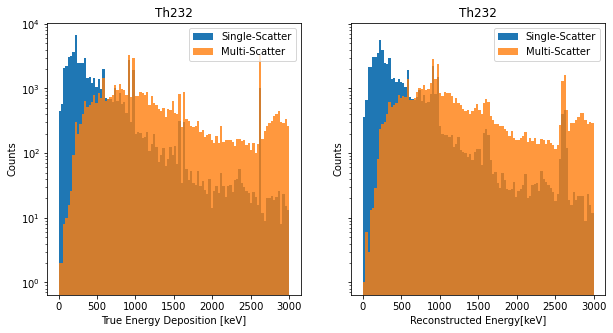

In [38]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,5), sharey=True)

alpha = 0.8
bins =np.linspace(0, 3000, 101)
ax1.hist(ss_Th_cryo, bins=bins, alpha = 1, label='Single-Scatter')
ax1.hist(ms_Th_cryo, bins=bins, alpha = alpha, label='Multi-Scatter')
ax1.set_xlabel('True Energy Deposition [keV]')
ax1.set_ylabel('Counts')
ax1.legend()
ax1.set_yscale('log')
ax1.set_title('Th232')

ax2.hist(energy_res(np.array(ss_Th_cryo)), bins=bins, alpha = 1, label='Single-Scatter')
ax2.hist(energy_res(np.array(ms_Th_cryo)), bins=bins, alpha = alpha, label='Multi-Scatter')
ax2.set_xlabel('Reconstructed Energy[keV]')
ax2.set_ylabel('Counts')
ax2.legend()
ax2.set_yscale('log')
ax2.set_title('Th232')

Assumed LXe Mass: 3.856795856133594 t


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1002/1002 [00:09<00:00, 104.05it/s]


U238 Cryostat 1002 189


0it [00:00, ?it/s]

No files found for key Cryostat, isotope Th232


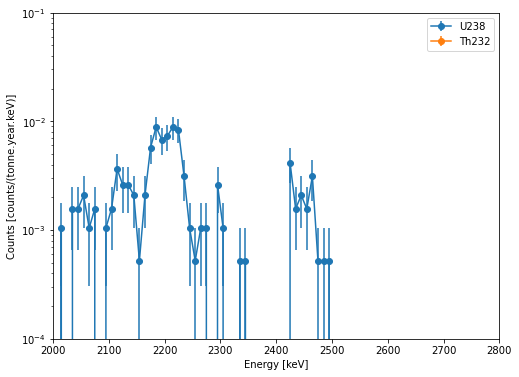

In [22]:
file_prefix = ''

#Constant Values for Scaling
lxe_density = 2.91
year = 3.154e7  #seconds
radius_cut = 375
z_max = 1350
z_min = -1650
height =(z_max-z_min)
volume = height/10*np.pi*(radius_cut/10)**2
mass_fv = (volume*lxe_density)/1e6
print(f"Assumed LXe Mass: {mass_fv} t" )

#Max Files
max_index=1500

energy_binning = np.linspace(2000, 3000, 101)
fig, ax = plt.subplots(figsize=(8, 6))
for isotope in ['U238', 'Th232']:
    background_hist = Histdd(bins=[energy_binning])
    binwidth = background_hist.bin_centers(0)[1]-background_hist.bin_centers(0)[0]
    errors=np.zeros_like(background_hist.bin_centers(0))
    for key, volume in act_dict.items():
        all_dfs = []
    
        # Search for all files matching the pattern for this key + isotope
        file_pattern = f'/storage/xenon/jacquesp/hermeticTPC/{key}_{isotope}_*.parquet'
        file_pattern = f'/storage/xenon/nadavh/hermeticTPC/BigStats_01/{key}/{isotope}/{key}_{isotope}_*_s10mm.parquet'
        matched_files = sorted(glob.glob(file_pattern))
        
        for filepath in tqdm(matched_files):
            filename = os.path.basename(filepath)
    
            # Use regex to extract serial number (handles zero-padding)
            match = re.match(rf'{re.escape(file_prefix)}{re.escape(key)}_{re.escape(isotope)}_(\d+)\_s10mm.parquet', filename)
            if match:
                serial_num = int(match.group(1))
                if serial_num > max_index:
                    continue
    
                # Load and collect DataFrame
                iso_vol_df = pd.read_parquet(filepath)

                #Find Single Scatters
                iso_vol_df = iso_vol_df[iso_vol_df['nclusters']==1]
                all_dfs.append(iso_vol_df)
                
            else:
                print(f"Skipping file (name format doesn't match): {filename}")
    
        # Concatenate all matching DataFrames
        if not all_dfs:
            print(f"No files found for key {key}, isotope {isotope}")
            continue

        file_loaded_counter = len(all_dfs)
        full_iso_vol_df = pd.concat(all_dfs, ignore_index=True)
    
        # Apply mask
        mask = (full_iso_vol_df['xp'] ** 2 + full_iso_vol_df['yp'] ** 2 < radius_cut ** 2)
        mask &= (full_iso_vol_df['zp'] < z_max) & (full_iso_vol_df['zp'] > z_min)
        mask &= (full_iso_vol_df['edep'] > 2000) & (full_iso_vol_df['edep'] < 3000)
        
        # Histogram calculation
        temp_hist = Histdd(
            energy_res(full_iso_vol_df[mask]['edep'].astype(float), 0.317, 1.7),
            bins=[energy_binning],
            )

        temp_errors = np.sqrt(temp_hist.histogram)
    
        if scale_dict[key][isotope] > 0:
            print(isotope, key, file_loaded_counter, len(full_iso_vol_df[mask]['edep']))
            background_hist.histogram += (
                (temp_hist.histogram / (1000 * scale_dict[key][isotope]* file_loaded_counter  * binwidth * mass_fv) * year ))
            errors += (temp_errors * (1 / (1000 * scale_dict[key][isotope]* file_loaded_counter  * binwidth * mass_fv) * year ))
    plt.errorbar(background_hist.bin_centers(0), background_hist.histogram, yerr = errors, marker = "o", label = isotope)
    #plt.yscale('log')

plt.legend()
plt.ylabel('Counts [counts/(tonne.year.keV)]')
plt.xlabel('Energy [keV]')
plt.ylim(0.0001, 0.10)
plt.xlim(2000, 2800)
plt.yscale('log')
plt.show()


Assumed LXe Mass: 46.350115533267726 t


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1002/1002 [00:09<00:00, 103.22it/s]


U238 Cryostat 1002 25


0it [00:00, ?it/s]

No files found for key Cryostat, isotope Th232


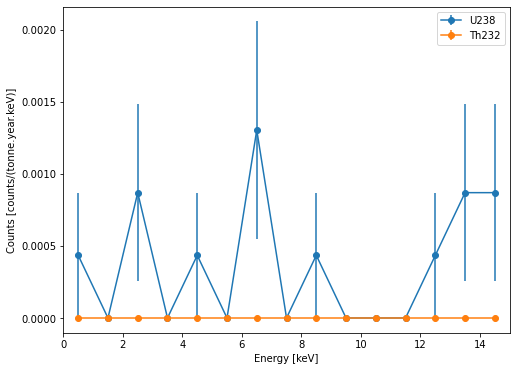

In [25]:
file_prefix = ''

#Constant Values for Scaling
lxe_density = 2.91
year = 3.154e7  #seconds
radius_cut = 1300
z_max = 1350
z_min = -1650
height =(z_max-z_min)
volume = height/10*np.pi*(radius_cut/10)**2
mass_fv = (volume*lxe_density)/1e6
print(f"Assumed LXe Mass: {mass_fv} t" )

#Max Files
max_index=1500

energy_binning = np.linspace(0, 15, 16)
fig, ax = plt.subplots(figsize=(8, 6))
for isotope in ['U238', 'Th232']:
    background_hist = Histdd(bins=[energy_binning])
    binwidth = background_hist.bin_centers(0)[1]-background_hist.bin_centers(0)[0]
    errors=np.zeros_like(background_hist.bin_centers(0))
    for key, volume in act_dict.items():
        all_dfs = []
    
        # Search for all files matching the pattern for this key + isotope
        file_pattern = f'/storage/xenon/jacquesp/hermeticTPC/{key}_{isotope}_*.parquet'
        file_pattern = f'/storage/xenon/nadavh/hermeticTPC/BigStats_01/{key}/{isotope}/{key}_{isotope}_*_s10mm.parquet'
        matched_files = sorted(glob.glob(file_pattern))
        
        for filepath in tqdm(matched_files):
            filename = os.path.basename(filepath)
    
            # Use regex to extract serial number (handles zero-padding)
            match = re.match(rf'{re.escape(file_prefix)}{re.escape(key)}_{re.escape(isotope)}_(\d+)\_s10mm.parquet', filename)
            if match:
                serial_num = int(match.group(1))
                if serial_num > max_index:
                    continue
    
                # Load and collect DataFrame
                iso_vol_df = pd.read_parquet(filepath)

                #Find Single Scatters
                iso_vol_df = iso_vol_df[iso_vol_df['nclusters']==1]
                all_dfs.append(iso_vol_df)
                
            else:
                print(f"Skipping file (name format doesn't match): {filename}")
    
        # Concatenate all matching DataFrames
        if not all_dfs:
            print(f"No files found for key {key}, isotope {isotope}")
            continue

        file_loaded_counter = len(all_dfs)
        full_iso_vol_df = pd.concat(all_dfs, ignore_index=True)
    
        # Apply mask
        mask = (full_iso_vol_df['xp'] ** 2 + full_iso_vol_df['yp'] ** 2 < radius_cut ** 2)
        mask &= (full_iso_vol_df['zp'] < z_max) & (full_iso_vol_df['zp'] > z_min)
        mask &= (full_iso_vol_df['edep'] > 0) & (full_iso_vol_df['edep'] < 20)
        
        # Histogram calculation
        temp_hist = Histdd(
            energy_res(full_iso_vol_df[mask]['edep'].astype(float), 0.317, 1.7),
            bins=[energy_binning],
            )

        temp_errors = np.sqrt(temp_hist.histogram)
    
        if scale_dict[key][isotope] > 0:
            print(isotope, key, file_loaded_counter, len(full_iso_vol_df[mask]['edep']))
            background_hist.histogram += (
                (temp_hist.histogram / (1000 * scale_dict[key][isotope]* file_loaded_counter  * binwidth * mass_fv) * year ))
            errors += (temp_errors * (1 / (1000 * scale_dict[key][isotope]* file_loaded_counter  * binwidth * mass_fv) * year ))
    plt.errorbar(background_hist.bin_centers(0), background_hist.histogram, yerr = errors, marker = "o", label = isotope)
    #plt.yscale('log')

plt.legend()
plt.ylabel('Counts [counts/(tonne.year.keV)]')
plt.xlabel('Energy [keV]')
#plt.ylim(0.0001, 0.10)
plt.xlim(0, 15)
#plt.yscale('log')
plt.show()


Assumed LXe Mass: 2.883740546060186 t


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 398/398 [00:13<00:00, 30.39it/s]


U238 PMT 398 169


0it [00:00, ?it/s]


No files found for key Sapphire, isotope U238


...

Th232 PMT 389 330


0it [00:00, ?it/s]


No files found for key Sapphire, isotope Th232


0it [00:00, ?it/s]

No files found for key Cryostat, isotope Th232


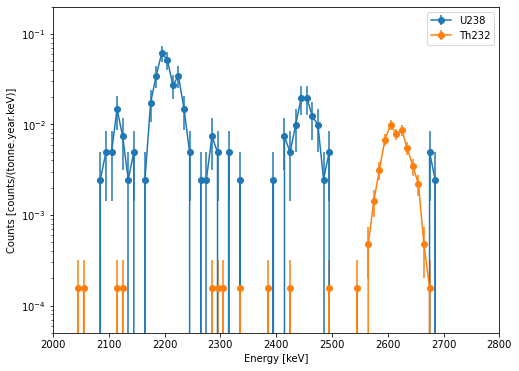

In [27]:
file_prefix = ''

#Constant Values for Scaling
lxe_density = 2.91
year = 3.154e7  #seconds
radius_cut = 350
z_max = 1125
z_min = -1450
height =(z_max-z_min)
volume = height/10*np.pi*(radius_cut/10)**2
mass_fv = (volume*lxe_density)/1e6
print(f"Assumed LXe Mass: {mass_fv} t" )

#Max Files
max_index=1000

energy_binning = np.linspace(2000, 3000, 101)
fig, ax = plt.subplots(figsize=(8, 6))
for isotope in ['U238', 'Th232']:
    background_hist = Histdd(bins=[energy_binning])
    binwidth = background_hist.bin_centers(0)[1]-background_hist.bin_centers(0)[0]
    errors=np.zeros_like(background_hist.bin_centers(0))
    for key, volume in act_dict.items():
        all_dfs = []
    
        # Search for all files matching the pattern for this key + isotope
        file_pattern = f'/storage/xenon/jacquesp/hermeticTPC/{key}_{isotope}_*.parquet'
        matched_files = sorted(glob.glob(file_pattern))
        
        for filepath in tqdm(matched_files):
            filename = os.path.basename(filepath)
    
            # Use regex to extract serial number (handles zero-padding)
            match = re.match(rf'{re.escape(file_prefix)}{re.escape(key)}_{re.escape(isotope)}_(\d+)\.parquet', filename)
            if match:
                serial_num = int(match.group(1))
                if serial_num > max_index:
                    continue
    
                # Load and collect DataFrame
                iso_vol_df = pd.read_parquet(filepath)

                #Find Single Scatters
                iso_vol_df = iso_vol_df[iso_vol_df['nclusters']==1]
                all_dfs.append(iso_vol_df)
                
            else:
                print(f"Skipping file (name format doesn't match): {filename}")
    
        # Concatenate all matching DataFrames
        if not all_dfs:
            print(f"No files found for key {key}, isotope {isotope}")
            continue

        file_loaded_counter = len(all_dfs)
        full_iso_vol_df = pd.concat(all_dfs, ignore_index=True)
    
        # Apply mask
        mask = (full_iso_vol_df['xp'] ** 2 + full_iso_vol_df['yp'] ** 2 < radius_cut ** 2)
        mask &= (full_iso_vol_df['zp'] < z_max) & (full_iso_vol_df['zp'] > z_min)
        mask &= (full_iso_vol_df['edep'] > 2000) & (full_iso_vol_df['edep'] < 3000)
        
        # Histogram calculation
        temp_hist = Histdd(
            energy_res(full_iso_vol_df[mask]['edep'].astype(float), 0.317, 1.7),
            bins=[energy_binning],
            )

        temp_errors = np.sqrt(temp_hist.histogram)
    
        if scale_dict[key][isotope] > 0:
            print(isotope, key, file_loaded_counter, len(full_iso_vol_df[mask]['edep']))
            background_hist.histogram += (
                (temp_hist.histogram / (1000 * scale_dict[key][isotope]* file_loaded_counter  * binwidth * mass_fv) * year ))
            errors += (temp_errors * (1 / (1000 * scale_dict[key][isotope]* file_loaded_counter  * binwidth * mass_fv) * year ))
    plt.errorbar(background_hist.bin_centers(0), background_hist.histogram, yerr = errors, marker = "o", label = isotope)
    #plt.yscale('log')

plt.legend()
plt.ylabel('Counts [counts/(tonne.year.keV)]')
plt.xlabel('Energy [keV]')
plt.ylim(0.00005, 0.2)
plt.xlim(2000, 2800)
plt.yscale('log')
plt.show()
